# RAFT (Retrieval Augmented Fine-Tuning) with Unsloth & LoRA

Notebook ini dibuat untuk melakukan fine-tuning model LLM menggunakan dataset RAFT (`raft_dataset_finalv1.jsonl` dan `raft_dataset_multi_oracle.jsonl`) dengan teknik LoRA (Low-Rank Adaptation) dan *library* Unsloth agar proses *training* jauh lebih cepat dan hemat memori.

### Mengapa RAFT Tahan Terhadap Distraktor?
Dalam paper jurnal **"RAFT: Adapting Language Model to Domain Specific RAG"** (Zhang et al., 2024), model tidak hanya dilatih untuk menjawab berdasarkan konteks yang relevan (Oracle), tetapi juga **sengaja diberikan dokumen distraktor (irrelevant/noise)**.
- Model dipaksa belajar melalui *Chain-of-Thought* (CoT) (dalam dataset Anda disebut `thought_process`) untuk memilah mana dokumen yang benar-benar relevan dan mana yang tidak.
- Untuk beberapa *training sample*, model bahkan dilatih untuk menolak menjawab jika tidak ada dokumen *oracle* sama sekali (100% distraktor).
- Hasilnya, model fine-tuning ini menjadi sangat robust (tahan uji) ketika di-deploy dalam sistem RAG nyata yang seringkali hasil *retrieval*-nya (dari Vector Database) kurang akurat atau mengandung banyak *noise*.

Referensi Jurnal:
- Zhang, D., et al. (2024). *RAFT: Adapting Language Model to Domain Specific RAG*. arXiv preprint arXiv:2403.10131. URL: https://arxiv.org/abs/2403.10131

In [2]:
# %%capture
# !pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
# !pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

### STEP 1: Cek Lingkungan (GPU & Library)

In [1]:
import torch
import transformers
import trl

print("=" * 60)
print("CEK LINGKUNGAN")
print("=" * 60)
print(f"PyTorch version   : {torch.__version__}")
print(f"Transformers ver  : {transformers.__version__}")
print(f"TRL version       : {trl.__version__}")
print(f"CUDA available    : {torch.cuda.is_available()}")
print(f"GPU count         : {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}            : {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"  Total memory    : {props.total_memory / 1024**3:.2f} GB")
        print(f"  Compute cap     : {props.major}.{props.minor}")
print("=" * 60)

assert torch.cuda.is_available(), "CUDA tidak tersedia! Pastikan GPU terdeteksi."

/workspace/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CEK LINGKUNGAN
PyTorch version   : 2.11.0+cu128
Transformers ver  : 5.5.0
TRL version       : 0.24.0
CUDA available    : True
GPU count         : 1
GPU 0            : NVIDIA B200
  Total memory    : 178.36 GB
  Compute cap     : 10.0


## 1. Load Model dengan Unsloth & Konfigurasi LoRA
Kita akan menggunakan model `Llama-3-8B-Instruct` sebagai *base model*. Unsloth menyediakan model dalam format 4-bit secara bawaan untuk penghematan memori.

In [2]:
from unsloth import FastLanguageModel
import torch

# =========================
# KONFIGURASI MODEL
# =========================
MODEL_NAME = "../model/Meta-Llama-3.1-8B-Instruct"
MAX_SEQ_LENGTH = 4096
DTYPE = None
LOAD_IN_4BIT = False

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=DTYPE,
    load_in_4bit=LOAD_IN_4BIT,
)

# =========================
# KONFIGURASI LoRA
# =========================
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=16,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("Model + LoRA berhasil dimuat.")

/workspace/.venv/lib/python3.10/site-packages/unsloth/__init__.py:153: UserWarning: WARNING: Unsloth should be imported before [trl, transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.9: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA B200. Num GPUs = 1. Max memory: 178.361 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 10.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 142.19it/s]
Unsloth: Will load ../model/Meta-Llama-3.1-8B-Instruct as a legacy tokenizer.


../model/Meta-Llama-3.1-8B-Instruct does not have a padding token! Will use pad_token = <|finetune_right_pad_id|>.


Unsloth 2026.6.9 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Model + LoRA berhasil dimuat.


## Load train & validation dataset

In [3]:
from datasets import load_dataset

# =========================
# PATH DATASET
# =========================
TRAIN_PATH = "/workspace/data/dataset/split/train.jsonl"
VAL_PATH   = "/workspace/data/dataset/split/val.jsonl"

# =========================
# LOAD DATASET
# =========================
train_raw = load_dataset("json", data_files=TRAIN_PATH, split="train")
val_raw   = load_dataset("json", data_files=VAL_PATH, split="train")

print(f"Jumlah data train : {len(train_raw)}")
print(f"Jumlah data val   : {len(val_raw)}")
print("Kolom train:", train_raw.column_names)
print("Kolom val  :", val_raw.column_names)

Jumlah data train : 399
Jumlah data val   : 45
Kolom train: ['instruction', 'documents', 'thought_process', 'completion']
Kolom val  : ['instruction', 'documents', 'thought_process', 'completion']


## Validasi struktur dataset

In [4]:
# =========================
# VALIDASI STRUKTUR DATASET
# =========================
REQUIRED_COLUMNS = ["instruction", "documents", "thought_process", "completion"]

def validate_dataset_schema(ds, name="dataset"):
    missing = [c for c in REQUIRED_COLUMNS if c not in ds.column_names]
    if missing:
        raise ValueError(f"{name} tidak memiliki kolom wajib: {missing}")
    print(f"[OK] {name} memiliki kolom yang dibutuhkan: {REQUIRED_COLUMNS}")

validate_dataset_schema(train_raw, "train_raw")
validate_dataset_schema(val_raw, "val_raw")

print("\nContoh 1 data train:")
print(train_raw[0])


[OK] train_raw memiliki kolom yang dibutuhkan: ['instruction', 'documents', 'thought_process', 'completion']
[OK] val_raw memiliki kolom yang dibutuhkan: ['instruction', 'documents', 'thought_process', 'completion']

Contoh 1 data train:
{'instruction': 'Apa langkah-langkah yang harus diikuti untuk pengucapan sumpah janji anggota BPD di Desa Cipedes setelah diterbitkannya keputusan bupati?', 'documents': ['[dokumen: Peraturan Desa Cipedes No. 04 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cipedes Kecamatan Paseh Kabupaten Bandung] [desa: cipedes] [kabupaten: bandung] [nomor: 04/2018]\n\npasal 13\n\n(2) pengucapan sumpah janji anggota bpd dipandu oleh bupati atau pejabat yang ditunjuk paling lama 30 (tiga puluh) hari sejak diterbitkannya keputusan bupati mengenai peresmian anggota bpd.', '[dokumen: Peraturan Desa Cipedes No. 04 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cipedes Kecamatan Paseh Kabupaten Bandung] [desa: cipedes] [kabupaten: bandung] [nomor: 04/2018]\

## 2. Persiapan & Formatting Dataset RAFT
Di sini kita akan memproses format dataset `raft_dataset_finalv1.jsonl` dan menyatukannya dalam struktur *prompt* instruksi. Model akan diajarkan untuk merangkai `<thought>` (Chain of Thought) terlebih dahulu untuk memilah dokumen distraktor sebelum memberikan jawaban akhir.

In [7]:
# from datasets import load_dataset, concatenate_datasets

# # --- Ganti path ini ke lokasi dataset jsonl Anda di Google Drive atau Local ---
# dataset_path_1 = "../data/dataset/raft_dataset_finalv2.jsonl"

# try:
#     ds1 = load_dataset("json", data_files=dataset_path_1, split="train")
    
#     cols_to_remove = ["metadata_extra", "validation"]
#     ds1 = ds1.remove_columns([c for c in cols_to_remove if c in ds1.column_names])

#     dataset = concatenate_datasets([ds1])
#     print(f"Berhasil dimuat! Total data: {len(dataset)} baris.")
    
# except Exception as e:
#     print(f"Error: {e}")

# # ==========================================
# # BAGIAN PROMPT DAN FORMATTING
# # ==========================================

# raft_prompt = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

# Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa. 
# Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat. 
# Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor). Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

# Pertanyaan: {instruction}

# Dokumen Referensi:
# {documents}
# <|eot_id|><|start_header_id|>assistant<|end_header_id|>

# <thought>
# {thought_process}
# </thought>

# {completion}"""

# EOS_TOKEN = tokenizer.eos_token # Harus menambahkan EOS_TOKEN di akhir

# def formatting_prompts_func(examples):
#     instructions = examples["instruction"]
#     docs_lists = examples["documents"]
#     thought_processes = examples["thought_process"]
#     completions = examples["completion"]
#     texts = []
    
#     for instruction, docs, thought, completion in zip(instructions, docs_lists, thought_processes, completions):
#         # Format ulang list dokumen menjadi bentuk teks terstruktur
#         formatted_docs = ""
#         for idx, doc in enumerate(docs):
#             formatted_docs += f"<doc id=\"{idx+1}\">\n{doc}\n</doc>\n\n"
            
#         # Apabila thought tidak ada (bisa terjadi jika belum di-generate secara utuh), skip atau buat default.
#         thought_text = thought if thought else "Tidak ada dokumen yang relevan."
        
#         text = raft_prompt.format(
#             instruction=instruction, 
#             documents=formatted_docs.strip(), 
#             thought_process=thought_text, 
#             completion=completion
#         ) + EOS_TOKEN
#         texts.append(text)
#     return { "text" : texts, }

# if 'dataset' in locals():
#     # Jalankan mapping data
#     dataset = dataset.map(formatting_prompts_func, batched = True, remove_columns=dataset.column_names)
#     print("\n--- Contoh Hasil Format Prompt Baris Pertama ---\n")
#     print(dataset[0]["text"])


In [5]:
# =========================
# PROMPT TEMPLATE
# =========================
RAFT_PROMPT = """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat.
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor).
Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{documents}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<thought>
{thought_process}
</thought>

{completion}"""

EOS_TOKEN = tokenizer.eos_token

def format_documents(docs):
    """
    Mengubah field documents menjadi string terstruktur.
    Mendukung jika docs berupa list[str] atau string biasa.
    """
    if docs is None:
        return "<doc id=\"1\">\n[Tidak ada dokumen]\n</doc>"

    if isinstance(docs, str):
        docs = [docs]

    formatted_docs = []
    for idx, doc in enumerate(docs, start=1):
        doc_text = str(doc).strip() if doc is not None else "[Dokumen kosong]"
        formatted_docs.append(f'<doc id="{idx}">\n{doc_text}\n</doc>')
    return "\n\n".join(formatted_docs)

def formatting_prompts_func(examples):
    instructions = examples["instruction"]
    docs_lists = examples["documents"]
    thought_processes = examples["thought_process"]
    completions = examples["completion"]

    texts = []
    for instruction, docs, thought, completion in zip(
        instructions, docs_lists, thought_processes, completions
    ):
        instruction = "" if instruction is None else str(instruction).strip()
        completion  = "" if completion is None else str(completion).strip()

        # Thought process fallback
        if thought is None or str(thought).strip() == "":
            thought_text = "Analisis tidak tersedia."
        else:
            thought_text = str(thought).strip()

        formatted_docs = format_documents(docs)

        text = RAFT_PROMPT.format(
            instruction=instruction,
            documents=formatted_docs,
            thought_process=thought_text,
            completion=completion,
        ) + EOS_TOKEN

        texts.append(text)

    return {"text": texts}

# =========================
# FORMAT TRAIN & VAL
# =========================
train_dataset = train_raw.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=train_raw.column_names,
    desc="Formatting train dataset"
)

val_dataset = val_raw.map(
    formatting_prompts_func,
    batched=True,
    remove_columns=val_raw.column_names,
    desc="Formatting validation dataset"
)

print(f"Train formatted: {len(train_dataset)}")
print(f"Val formatted  : {len(val_dataset)}")

print("\n=== CONTOH HASIL FORMAT TRAIN[0] ===\n")
print(train_dataset[0]["text"][:2500])

Train formatted: 399
Val formatted  : 45

=== CONTOH HASIL FORMAT TRAIN[0] ===

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat.
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor).
Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: Apa langkah-langkah yang harus diikuti untuk pengucapan sumpah janji anggota BPD di Desa Cipedes setelah diterbitkannya keputusan bupati?

Dokumen Referensi:
<doc id="1">
[dokumen: Peraturan Desa Cipedes No. 04 Tahun 2018 - Badan Permusyawaratan Desa (Bpd) Di Desa Cipedes Kecamatan Paseh Kabupaten Bandung] [desa: cipedes] [kabupaten: bandung] [nomor: 04/2018]

pasal 13

(2

## Sanity check token length

##### Ini berguna untuk tahu apakah ada data terlalu panjang.

In [6]:
# =========================
# CEK PANJANG TOKEN
# =========================
def inspect_token_lengths(ds, sample_size=50):
    sample_size = min(sample_size, len(ds))
    lengths = []
    for i in range(sample_size):
        tokenized = tokenizer(ds[i]["text"], truncation=False)
        lengths.append(len(tokenized["input_ids"]))
    return lengths

lengths = inspect_token_lengths(train_dataset, sample_size=50)
print(f"Sample token length - min: {min(lengths)}, max: {max(lengths)}, avg: {sum(lengths)/len(lengths):.2f}")

Sample token length - min: 576, max: 2221, avg: 1564.68


## 3. Training Menggunakan SFTTrainer dari TRL

In [10]:
# from trl import SFTTrainer, SFTConfig
# from unsloth import is_bfloat16_supported

# LEARNING_RATE     = 2e-4
# NUM_EPOCHS        = 5
# WARMUP_STEPS      = 5
# BATCH_SIZE        = 16   # Optimasi B200 (191 GB VRAM)
# GRAD_ACCUM_STEPS  = 2    # Effective batch size = 32
# WEIGHT_DECAY      = 0.02
# MAX_SEQ_LENGTH    = 2048 # <--- Add this line!

# steps_per_epoch = max(1, len(dataset) // (BATCH_SIZE * GRAD_ACCUM_STEPS))
# MAX_STEPS       = steps_per_epoch * NUM_EPOCHS

# sft_config = SFTConfig(
#     dataset_text_field="text",
#     max_seq_length=MAX_SEQ_LENGTH,
#     dataset_num_proc=2,
#     packing=False,
#     per_device_train_batch_size=BATCH_SIZE,
#     gradient_accumulation_steps=GRAD_ACCUM_STEPS,
#     warmup_steps=WARMUP_STEPS,
#     max_steps=MAX_STEPS,
#     learning_rate=LEARNING_RATE,
#     fp16=not is_bfloat16_supported(),
#     bf16=is_bfloat16_supported(),
#     logging_steps=1,
#     optim="adamw_8bit",
#     weight_decay=WEIGHT_DECAY,
#     lr_scheduler_type="linear",
#     seed=3407,
#     output_dir="outputs_lora",
#     logging_dir="outputs_lora/tensorboard_logs",
#     report_to="none",
#     save_strategy="steps",
#     save_steps=steps_per_epoch,
#     save_total_limit=3,
# )

# trainer = SFTTrainer(
#     model=model,
#     tokenizer=tokenizer,
#     train_dataset=dataset,
#     args=sft_config,
# )

# print("\n>>> Memulai training...")
# trainer_stats = trainer.train() 


In [7]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
from transformers import EarlyStoppingCallback
import math
import os

# =========================
# BASE OUTPUT DIR
# =========================
BASE_MODEL_DIR = "/workspace/model"
TRAIN_OUTPUT_DIR = os.path.join(BASE_MODEL_DIR, "outputs_lora")
LOGGING_DIR = os.path.join(TRAIN_OUTPUT_DIR, "tensorboard_logs")

os.makedirs(TRAIN_OUTPUT_DIR, exist_ok=True)
os.makedirs(LOGGING_DIR, exist_ok=True)

# Untuk menghindari warning logging_dir deprecated
os.environ["TENSORBOARD_LOGGING_DIR"] = LOGGING_DIR

# =========================
# HYPERPARAMETER
# =========================
LEARNING_RATE = 2e-4
NUM_EPOCHS = 5
BATCH_SIZE = 16
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.02
TRAIN_MAX_SEQ_LENGTH = 2048

effective_batch_size = BATCH_SIZE * GRAD_ACCUM_STEPS
steps_per_epoch = math.ceil(len(train_dataset) / effective_batch_size)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total epoch    : {NUM_EPOCHS}")

# =========================
# WARMUP
# =========================
# ganti warmup_ratio -> warmup_steps
warmup_steps = max(1, int(0.03 * steps_per_epoch * NUM_EPOCHS))

# =========================
# EVAL & SAVE
# =========================
# Supaya kompatibel dengan load_best_model_at_end,
# save_steps harus kelipatan eval_steps.
# Paling aman: evaluasi + save tiap akhir epoch.
eval_steps = steps_per_epoch
save_steps = steps_per_epoch

print(f"Eval every {eval_steps} steps")
print(f"Save every {save_steps} steps")
print(f"Warmup steps: {warmup_steps}")

sft_config = SFTConfig(
    dataset_text_field="text",
    max_seq_length=TRAIN_MAX_SEQ_LENGTH,
    dataset_num_proc=2,
    packing=False,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,

    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,

    fp16=not is_bfloat16_supported(),
    bf16=is_bfloat16_supported(),

    logging_steps=13,
    optim="adamw_8bit",
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type="linear",
    seed=3407,

    # =========================
    # OUTPUT TRAINER
    # =========================
    output_dir=TRAIN_OUTPUT_DIR,
    report_to="tensorboard",

    # =========================
    # EVALUATION
    # =========================
    eval_strategy="steps",
    eval_steps=eval_steps,

    # =========================
    # CHECKPOINT
    # =========================
    save_strategy="steps",
    save_steps=save_steps,
    save_total_limit=3,

    # =========================
    # PILIH MODEL TERBAIK
    # =========================
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    args=sft_config,
)

# Early stopping: stop jika eval_loss tidak membaik
trainer.add_callback(EarlyStoppingCallback(early_stopping_patience=2))

print("\nTrainer siap. Akan memantau train loss dan validation loss.")
print(f"Checkpoint trainer akan disimpan di: {TRAIN_OUTPUT_DIR}")
print(f"TensorBoard log akan disimpan di   : {LOGGING_DIR}")

Steps per epoch: 13
Total epoch    : 5
Eval every 13 steps
Save every 13 steps
Warmup steps: 1
🦥 Unsloth: Padding-free auto-enabled, enabling faster training.

Trainer siap. Akan memantau train loss dan validation loss.
Checkpoint trainer akan disimpan di: /workspace/model/outputs_lora
TensorBoard log akan disimpan di   : /workspace/model/outputs_lora/tensorboard_logs


In [8]:
print("\n>>> Memulai training...")
trainer_stats = trainer.train()

print("\n>>> Training selesai.")
print("Best checkpoint :", trainer.state.best_model_checkpoint)
print("Best metric     :", trainer.state.best_metric)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.



>>> Memulai training...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 399 | Num Epochs = 5 | Total steps = 65
O^O/ \_/ \    Batch size per device = 16 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (16 x 2 x 1) = 32
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
13,0.721862,0.458318
26,0.403708,0.368468
39,0.324049,0.315710
52,0.268482,0.283093
65,0.235583,0.270221


Unsloth: Restored added_tokens_decoder metadata in /workspace/model/outputs_lora/checkpoint-13/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/outputs_lora/checkpoint-26/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/outputs_lora/checkpoint-39/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/outputs_lora/checkpoint-52/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/outputs_lora/checkpoint-65/tokenizer_config.json.



>>> Training selesai.
Best checkpoint : /workspace/model/outputs_lora/checkpoint-65
Best metric     : 0.27022117376327515


## Train loss + Validation loss

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.721862,0.210584,0.000166,1.0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,13,0.458318,18.5725,2.423,0.162,NaN,NaN,NaN,NaN,NaN
2,0.403708,0.160017,0.000125,2.0,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,26,0.368468,12.2685,3.668,0.245,NaN,NaN,NaN,NaN,NaN
4,0.324049,0.222502,0.000084,3.0,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,39,0.315710,12.2864,3.663,0.244,NaN,NaN,NaN,NaN,NaN
6,0.268482,0.220053,0.000044,4.0,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,52,0.283093,12.3016,3.658,0.244,NaN,NaN,NaN,NaN,NaN
8,0.235583,0.211650,0.000003,5.0,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,5.0,65,0.270221,12.2471,3.674,0.245,NaN,NaN,NaN,NaN,NaN


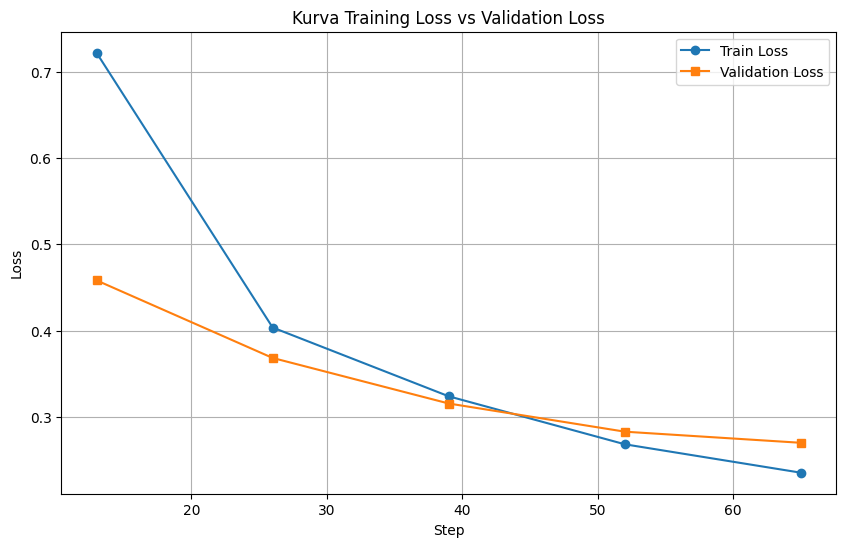

Train loss terakhir:


,step,loss
0,13,0.721862
2,26,0.403708
4,39,0.324049
6,52,0.268482
8,65,0.235583


Validation loss terakhir:


,step,eval_loss
1,13,0.458318
3,26,0.368468
5,39,0.315710
7,52,0.283093
9,65,0.270221


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# AMBIL LOG HISTORY
# =========================
log_history = trainer.state.log_history
log_df = pd.DataFrame(log_history)

display(log_df.tail(20))

# Train loss
train_logs = log_df[log_df["loss"].notna()].copy() if "loss" in log_df.columns else pd.DataFrame()

# Eval loss
eval_logs = log_df[log_df["eval_loss"].notna()].copy() if "eval_loss" in log_df.columns else pd.DataFrame()

plt.figure(figsize=(10, 6))

if not train_logs.empty:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Train Loss")

if not eval_logs.empty:
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="Validation Loss")

plt.title("Kurva Training Loss vs Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

if not train_logs.empty:
    print("Train loss terakhir:")
    display(train_logs[["step", "loss"]].tail())

if not eval_logs.empty:
    print("Validation loss terakhir:")
    display(eval_logs[["step", "eval_loss"]].tail())

## Ringkasan metrik training

In [10]:
metrics = trainer_stats.metrics

print("=" * 60)
print("RINGKASAN TRAINING")
print("=" * 60)
for k, v in metrics.items():
    print(f"{k}: {v}")

print("=" * 60)
print(f"Best checkpoint : {trainer.state.best_model_checkpoint}")
print(f"Best eval loss  : {trainer.state.best_metric}")
print("=" * 60)

RINGKASAN TRAINING
train_runtime: 1474.3709
train_samples_per_second: 1.353
train_steps_per_second: 0.044
total_flos: 1.3303346715475968e+17
train_loss: 0.39073653587928187
epoch: 5.0
Best checkpoint : /workspace/model/outputs_lora/checkpoint-65
Best eval loss  : 0.27022117376327515


## Evaluasi generatif pada validation set

In [ ]:
from unsloth import FastLanguageModel
import pandas as pd
from tqdm import tqdm
import torch
import re
import ast
import json


FastLanguageModel.for_inference(model)

def build_inference_prompt(instruction, documents):
    formatted_docs = format_documents(documents)

    prompt = f"""<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Anda adalah asisten AI ahli dalam menjawab pertanyaan berdasarkan dokumen hukum dan peraturan desa.
Diberikan sejumlah dokumen referensi, analisislah dokumen tersebut untuk mencari jawaban yang tepat.
Tuliskan proses berpikir Anda di dalam tag <thought>...</thought> dengan menjelaskan dokumen mana yang relevan dan tidak relevan (distraktor).
Setelah itu, berikan jawaban akhir Anda berdasarkan hasil analisis tersebut.<|eot_id|><|start_header_id|>user<|end_header_id|>

Pertanyaan: {instruction}

Dokumen Referensi:
{formatted_docs}
<|eot_id|><|start_header_id|>assistant<|end_header_id|>

<thought>
"""
    return prompt



def clean_generated_answer(text):
    if text is None:
        return ""

    text = str(text).strip()

    # hapus special token dasar
    special_tokens = [
        "<|eot_id|>",
        "<|start_header_id|>",
        "<|end_header_id|>",
        "<|begin_of_text|>",
    ]
    for tok in special_tokens:
        text = text.replace(tok, "")

    text = text.strip()

    if "</thought>" in text:
        after_thought = text.split("</thought>", 1)[-1].strip()
    else:
        after_thought = text

    candidate = after_thought.strip()

    try:
        obj = ast.literal_eval(candidate)
        if isinstance(obj, dict):
            for key in ["final_answer", "answer", "response"]:
                if key in obj and obj[key]:
                    return str(obj[key]).strip()
    except Exception:
        pass

    try:
        obj = json.loads(candidate)
        if isinstance(obj, dict):
            for key in ["final_answer", "answer", "response"]:
                if key in obj and obj[key]:
                    return str(obj[key]).strip()
    except Exception:
        pass

    m = re.search(r'"?final_answer"?\s*:\s*"([^"]+)"', candidate, flags=re.DOTALL | re.IGNORECASE)
    if m:
        return m.group(1).strip()


    return candidate.strip()

def generate_answer_only(model, tokenizer, instruction, documents, max_new_tokens=256):
    prompt = build_inference_prompt(instruction, documents)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
    ).to(model.device)

    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Ambil hanya token hasil generasi model
    generated_ids = outputs[0][input_len:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=False)

    final_answer = clean_generated_answer(generated_text)

    return {
        "prompt": prompt,
        "raw_generation": generated_text,   # output mentah model
        "final_answer": final_answer,       # jawaban akhir yang sudah dibersihkan
    }

In [12]:
N_EVAL_SAMPLES = min(20, len(val_raw))
rows = []

for i in tqdm(range(N_EVAL_SAMPLES), desc="Evaluating validation samples"):
    row = val_raw[i]

    instruction = row["instruction"]
    documents = row["documents"]
    reference = row["completion"]

    result = generate_answer_only(
        model=model,
        tokenizer=tokenizer,
        instruction=instruction,
        documents=documents,
        max_new_tokens=256
    )

    rows.append({
        "idx": i,
        "instruction": instruction,
        "reference": reference,
        "prediction_raw": result["raw_generation"],
        "prediction_final": result["final_answer"],
    })

eval_df = pd.DataFrame(rows)

display(
    eval_df[["idx", "instruction", "reference", "prediction_final"]].head(10)
)

Evaluating validation samples:   0%|          | 0/20 [00:00<?, ?it/s]Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/workspace/.venv/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_uti

,idx,instruction,reference,prediction_final
0,0,Apa syarat-syarat yang harus dipenuhi oleh cal...,Syarat-syarat yang harus dipenuhi oleh calon a...,"{'document_analysis': [{'document': 1, 'analys..."
1,1,Apa kewajiban unit pengelola air bersih terkai...,Unit pengelola air bersih wajib memberikan lap...,"{'document_analysis': [{'document': 1, 'analys..."
2,2,Gimana sih cara milih anggota BPD yang baru? A...,Cara memilih anggota BPD yang baru melibatkan ...,"{'document_analysis': [{'document': 1, 'analys..."
3,3,"BPD itu apa sih, fungsinya buat apa di desa?",BPD (Badan Permusyawaratan Desa) adalah lembag...,"{'document_analysis': [{'document': 1, 'analys..."
4,4,"Apa yang dimaksud dengan ""pemerintahan desa"" m...",Pemerintahan desa adalah penyelenggara urusan ...,"{'document_analysis': [{'document': 1, 'analys..."
5,5,"Apa yang dimaksud dengan ""kibbla"" menurut Pera...",Kibbla menurut Peraturan Desa Biru No. 07 Tahu...,"{'document_analysis': [{'document': 1, 'analys..."
6,6,Apa langkah-langkah yang harus dilakukan setel...,"Setelah berita acara musyawarah desa disusun, ...","{'document_analysis': [{'document': 1, 'analys..."
7,7,Apa saja upaya kuratif yang dilakukan sesuai d...,Upaya kuratif yang dilakukan sesuai dengan Pas...,"{'document_analysis': [{'document': 1, 'analys..."
8,8,Apa yang dimaksud dengan profil desa menurut P...,Profil desa menurut Peraturan Desa Cipedes No....,"{'document_analysis': [{'document': 1, 'analys..."
9,9,Apa langkah-langkah yang harus dilakukan oleh ...,Sekretaris desa harus mengundangkan peraturan ...,"{'document_analysis': [{'document': 1, 'analys..."


## Skor sederhana berbasis exact match longgar

In [13]:
import re

def normalize_text(s):
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


def token_overlap_score(pred, ref):
    pred_tokens = set(normalize_text(pred).split())
    ref_tokens = set(normalize_text(ref).split())
    if len(ref_tokens) == 0:
        return 0.0
    return len(pred_tokens & ref_tokens) / len(ref_tokens)


eval_df["token_overlap"] = eval_df.apply(
    lambda x: token_overlap_score(x["prediction_final"], x["reference"]),
    axis=1
)

print("Avg token overlap:", eval_df["token_overlap"].mean())

display(
    eval_df[
        ["idx", "instruction", "reference", "prediction_final", "token_overlap"]
    ].head(10)
)

Avg token overlap: 0.6276425976932443


,idx,instruction,reference,prediction_final,token_overlap
0,0,Apa syarat-syarat yang harus dipenuhi oleh cal...,Syarat-syarat yang harus dipenuhi oleh calon a...,"{'document_analysis': [{'document': 1, 'analys...",0.175000
1,1,Apa kewajiban unit pengelola air bersih terkai...,Unit pengelola air bersih wajib memberikan lap...,"{'document_analysis': [{'document': 1, 'analys...",0.638889
2,2,Gimana sih cara milih anggota BPD yang baru? A...,Cara memilih anggota BPD yang baru melibatkan ...,"{'document_analysis': [{'document': 1, 'analys...",0.617021
3,3,"BPD itu apa sih, fungsinya buat apa di desa?",BPD (Badan Permusyawaratan Desa) adalah lembag...,"{'document_analysis': [{'document': 1, 'analys...",0.843750
4,4,"Apa yang dimaksud dengan ""pemerintahan desa"" m...",Pemerintahan desa adalah penyelenggara urusan ...,"{'document_analysis': [{'document': 1, 'analys...",0.866667
5,5,"Apa yang dimaksud dengan ""kibbla"" menurut Pera...",Kibbla menurut Peraturan Desa Biru No. 07 Tahu...,"{'document_analysis': [{'document': 1, 'analys...",0.318182
6,6,Apa langkah-langkah yang harus dilakukan setel...,"Setelah berita acara musyawarah desa disusun, ...","{'document_analysis': [{'document': 1, 'analys...",0.866667
7,7,Apa saja upaya kuratif yang dilakukan sesuai d...,Upaya kuratif yang dilakukan sesuai dengan Pas...,"{'document_analysis': [{'document': 1, 'analys...",0.585366
8,8,Apa yang dimaksud dengan profil desa menurut P...,Profil desa menurut Peraturan Desa Cipedes No....,"{'document_analysis': [{'document': 1, 'analys...",0.611111
9,9,Apa langkah-langkah yang harus dilakukan oleh ...,Sekretaris desa harus mengundangkan peraturan ...,"{'document_analysis': [{'document': 1, 'analys...",0.800000


## DEMO INFERENCE

In [21]:
FastLanguageModel.for_inference(model)

test_instruction = "Siapa saja unsur masyarakat yang diundang dan harus hadir dalam Musyawarah Desa pemilihan kewenangan di Desa Cigentur?"
test_docs = [
    "unsur masyarakat  Musyawarah Desa pemilihan kewenangan di Desa cigentur dimaksud pada ayat (1) terdiri dari : a. perwakilan perangkat desa;\nb. anggota badan permusyawaratan desa (bpd);\nc. perwakilan kecamatan;\nd. perwakilan pengusaha lokal;\ne. ketua rukun warga (rw).",
"unsur masyarakat sebagaimana dimaksud pada ayat (1) terdiri dari : a. tokoh agama;\nb. tokoh masyarakat;\nc. tokoh pendidik;\nd. perwakilan kelompok tani;\ne. perwakilan kelompok perajin;\nf. perwakilan kelompok perempuan;\ng. perwakilan kelompok pemerhati dan perlindungan anak; dan\nh. perwakilan kelompok masyarakat miskin."
]

test_result = generate_answer_only(
    model=model,
    tokenizer=tokenizer,
    instruction=test_instruction,
    documents=test_docs,
    max_new_tokens=2000
)

print("=== RAW GENERATION ===")
print(test_result["raw_generation"])

print("\n=== FINAL ANSWER ===")
print(test_result["final_answer"])

Both `max_new_tokens` (=2000) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== RAW GENERATION ===
{'document_analysis': [{'document': 1, 'analysis': 'Dokumen ini menyebutkan unsur masyarakat yang diundang dalam Musyawarah Desa pemilihan kewenangan di Desa Cigentur, termasuk perwakilan perangkat desa, anggota BPD, perwakilan kecamatan, perwakilan pengusaha lokal, dan ketua RW. Informasi ini relevan karena secara langsung menjawab pertanyaan mengenai unsur masyarakat yang diundang.', 'negative_type': None}, {'document': 2, 'analysis': 'Dokumen ini juga menyebutkan unsur masyarakat yang diundang dalam Musyawarah Desa, tetapi dengan daftar yang berbeda. Meskipun informasi ini tampak relevan, dokumen ini tidak dapat dijadikan dasar jawaban yang benar karena tidak mencakup unsur masyarakat yang disebutkan dalam dokumen pertama.', 'negative_type': None}],'summary': 'Dokumen pertama memberikan daftar unsur masyarakat yang diundang dalam Musyawarah Desa pemilihan kewenangan di Desa Cigentur, sementara dokumen kedua tidak relevan karena menyebutkan unsur yang berbeda.'

## SAVE MODEL

In [17]:
# =========================
# SAVE LoRA ADAPTER
# =========================
ADAPTER_DIR = "/workspace/model/lora_adapter_raft_perdes_best"
MERGED_DIR  = "/workspace/model/model_merged_raft_perdes_best"

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"LoRA adapter disimpan ke: {ADAPTER_DIR}")

# =========================
# SAVE MERGED MODEL
# =========================
model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit"
)

print(f"Merged model disimpan ke: {MERGED_DIR}")

Unsloth: Restored added_tokens_decoder metadata in /workspace/model/lora_adapter_raft_perdes_best/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /workspace/model/model_merged_raft_perdes_best/tokenizer_config.json.


LoRA adapter disimpan ke: /workspace/model/lora_adapter_raft_perdes_best
Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct
Found HuggingFace hub cache directory: /home/kel07/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:00<00:01,  2.34it/s]

Copied model-00004-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files:  50%|█████     | 2/4 [00:02<00:02,  1.24s/it]

...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:05<00:00,  1.47s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:29<00:00,  7.49s/it]


Unsloth: Merge process complete. Saved to `/workspace/model/model_merged_raft_perdes_best`
Merged model disimpan ke: /workspace/model/model_merged_raft_perdes_best


## Ringkasan kesimpulan untuk bukti anti-overfitting

In [16]:
import pandas as pd

summary = {
    "jumlah_train": len(train_dataset),
    "jumlah_val": len(val_dataset),
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_eval_loss": trainer.state.best_metric,
}

summary_df = pd.DataFrame([summary])
display(summary_df)

print("""
INTERPRETASI:
1. Model dilatih menggunakan train set dan dievaluasi pada validation set yang terpisah.
2. Selama training, train loss dan validation loss dipantau.
3. Model terbaik dipilih berdasarkan validation loss terendah (best checkpoint).
4. Jika validation loss tidak meningkat tajam saat training berlangsung dan performa pada validation/hold-out tetap baik,
   maka model memiliki indikasi generalisasi yang lebih baik dan tidak sekadar menghafal data train.
""")

,jumlah_train,jumlah_val,best_checkpoint,best_eval_loss
0,399,45,/workspace/model/outputs_lora/checkpoint-65,0.270221



INTERPRETASI:
1. Model dilatih menggunakan train set dan dievaluasi pada validation set yang terpisah.
2. Selama training, train loss dan validation loss dipantau.
3. Model terbaik dipilih berdasarkan validation loss terendah (best checkpoint).
4. Jika validation loss tidak meningkat tajam saat training berlangsung dan performa pada validation/hold-out tetap baik,
   maka model memiliki indikasi generalisasi yang lebih baik dan tidak sekadar menghafal data train.




>>> [INFO] Grafik Training Loss sedang dibuat...
>>> [INFO] Waktu Aktual Training: 27 menit 23 detik
>>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'


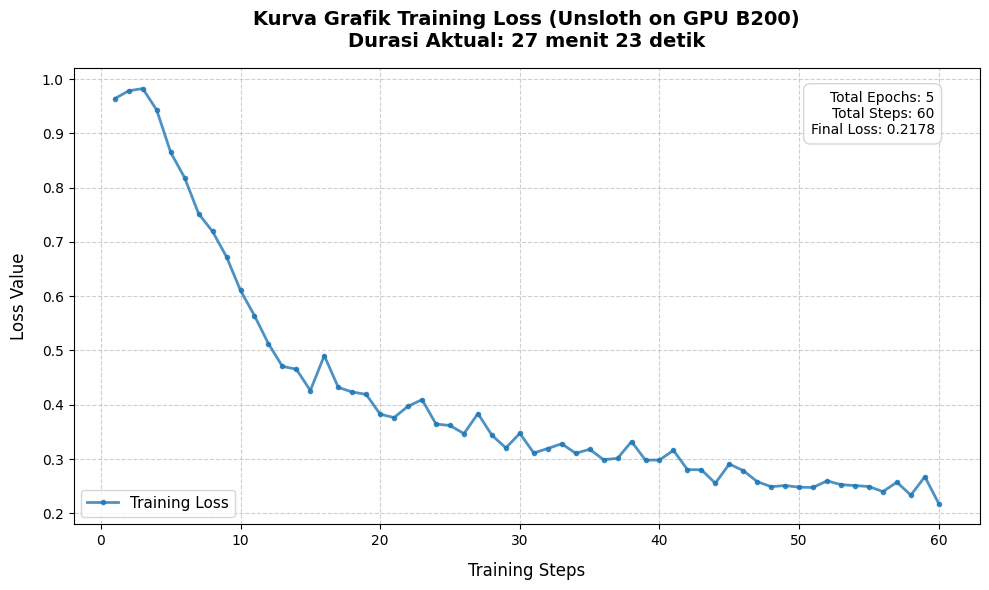

In [ ]:
# import matplotlib.pyplot as plt

# # 1. Ambil log history untuk visualisasi Training Loss
# log_history = trainer.state.log_history

# # Saring data untuk mengambil langkah yang berisi 'loss' (bukan evaluasi)
# steps = [log.get("step") for log in log_history if "loss" in log]
# losses = [log.get("loss") for log in log_history if "loss" in log]

# # 2. Ambil waktu aktual dari trainer_stats
# metrics = trainer_stats.metrics
# total_seconds = metrics.get("train_runtime", 0)

# # Konversi detik ke jam, menit, dan detik
# hours = int(total_seconds // 3600)
# minutes = int((total_seconds % 3600) // 60)
# seconds = int(total_seconds % 60)

# # Format teks durasi waktu aktual
# waktu_aktual = f"{hours} jam {minutes} menit {seconds} detik" if hours > 0 else f"{minutes} menit {seconds} detik"

# print(f"\n>>> [INFO] Grafik Training Loss sedang dibuat...")
# print(f">>> [INFO] Waktu Aktual Training: {waktu_aktual}")

# # 3. Membuat Grafik Visualisasi Training Loss
# plt.figure(figsize=(10, 6))

# # Plot kurva loss (Warna biru tua khas visualisasi profesional)
# plt.plot(steps, losses, label="Training Loss", color="#1f77b4", linewidth=2, marker='o', markersize=3, alpha=0.8)

# # Kostumisasi tampilan grafik
# plt.title(f"Kurva Grafik Training Loss (Unsloth on GPU B200)\nDurasi Aktual: {waktu_aktual}", fontsize=14, fontweight='bold', pad=15)
# plt.xlabel("Training Steps", fontsize=12, labelpad=10)
# plt.ylabel("Loss Value", fontsize=12, labelpad=10)
# plt.grid(True, linestyle="--", alpha=0.6)
# plt.legend(fontsize=11)

# # Tambahkan catatan teks info di dalam grafik (opsional)
# info_text = f"Total Epochs: {NUM_EPOCHS}\nTotal Steps: {max(steps) if steps else MAX_STEPS}\nFinal Loss: {losses[-1]:.4f}"
# plt.gca().text(0.95, 0.95, info_text, transform=plt.gca().transAxes, fontsize=10,
#             verticalalignment='top', horizontalalignment='right',
#             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='#ccc'))

# plt.tight_layout()

# # 4. Simpan dan Tampilkan Gambar
# plt.savefig("outputs_lora/training_loss_curve_v3.png", dpi=300)
# print(">>> [SUKSES] Grafik berhasil disimpan di 'outputs_lora/training_loss_curve.png'")
# plt.show()


## 5. Menyimpan LoRA Adapter
Setelah puas dengan hasil *fine-tuning*, kita bisa menyimpan model atau adapter LoRA-nya saja.

In [ ]:
model.save_pretrained("lora_adapter_raft_perdes_v3")
tokenizer.save_pretrained("model_merged_raft_perdes_v3")

Unsloth: Restored added_tokens_decoder metadata in model_merged_raft_perdes_v2/tokenizer_config.json.


('model_merged_raft_perdes_v2/tokenizer_config.json',
 'model_merged_raft_perdes_v2/chat_template.jinja',
 'model_merged_raft_perdes_v2/tokenizer.json')

In [7]:
# Ini cara yang BENAR untuk menyimpan LoRA Adapter beserta Tokenizer-nya
model.save_pretrained("lora_adapter_raft_perdes_v4")
tokenizer.save_pretrained("lora_adapter_raft_perdes_v4")


Unsloth: Restored added_tokens_decoder metadata in lora_adapter_raft_perdes_v4/tokenizer_config.json.


('lora_adapter_raft_perdes_v4/tokenizer_config.json',
 'lora_adapter_raft_perdes_v4/chat_template.jinja',
 'lora_adapter_raft_perdes_v4/tokenizer.json')

In [10]:
# Ini cara yang BENAR untuk menyimpan Merged Model (digabung penuh)
model.save_pretrained_merged("model_merged_raft_perdes_v3", tokenizer, save_method="merged_16bit")


Detected local model directory: /workspace/model/Meta-Llama-3.1-8B-Instruct


RuntimeError: Failed saving - no disk space left!